##**Project - Spam Email Detection**

In [23]:
from google.colab import files

uploaded = files.upload()

Saving spam_mail_dataset.csv to spam_mail_dataset (1).csv


In [24]:
!pip install pandas scikit-learn matplotlib

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
df = pd.read_csv("spam_mail_dataset.csv")

print(df.head())
print("\nDataset Shape:", df.shape)

  label                              message
0   ham               Hi, how are you today?
1   ham    Are you coming to class tomorrow?
2   ham  Please send me the assignment file.
3   ham        I will call you after dinner.
4   ham  Your meeting is scheduled for 3 PM.

Dataset Shape: (59, 2)


In [27]:
print(df.columns)

Index(['label', 'message'], dtype='object')


In [28]:
df = df[["label", "message"]]

df = df.dropna()

df["label"] = df["label"].str.lower().str.strip()

print(df.isnull().sum())

print("\nClass Distribution:")
print(df["label"].value_counts())

label      0
message    0
dtype: int64

Class Distribution:
label
ham     30
spam    29
Name: count, dtype: int64


In [29]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print(df.head())

   label                              message
0      0               Hi, how are you today?
1      0    Are you coming to class tomorrow?
2      0  Please send me the assignment file.
3      0        I will call you after dinner.
4      0  Your meeting is scheduled for 3 PM.


In [30]:
X = df["message"].astype(str)
y = df["label"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 47
Testing Samples: 12


In [32]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_vector = vectorizer.fit_transform(X_train)
X_test_vector = vectorizer.transform(X_test)

print("Training Vector Shape:", X_train_vector.shape)

Training Vector Shape: (47, 120)


In [33]:
model = MultinomialNB()

model.fit(X_train_vector, y_train)

print("Model trained successfully!")

Model trained successfully!


In [34]:
y_pred = model.predict(X_test_vector)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 83.33 %


In [35]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       1.00      0.67      0.80         6
        Spam       0.75      1.00      0.86         6

    accuracy                           0.83        12
   macro avg       0.88      0.83      0.83        12
weighted avg       0.88      0.83      0.83        12



In [36]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4 2]
 [0 6]]


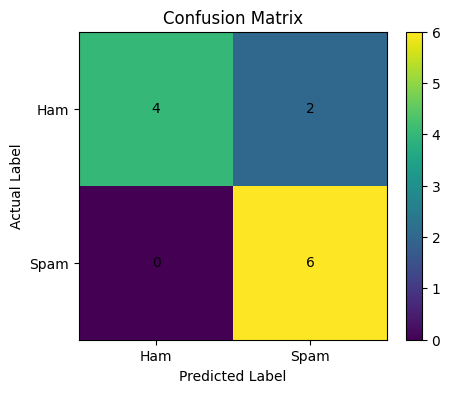

In [37]:
plt.figure(figsize=(5, 4))

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()

plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [38]:
def predict_spam(message):
    message_vector = vectorizer.transform([message])

    prediction = model.predict(message_vector)[0]
    probability = model.predict_proba(message_vector)[0]

    if prediction == 1:
        print("🚨 Result: SPAM")
        print("Spam Probability:", round(probability[1] * 100, 2), "%")
    else:
        print("✅ Result: NOT SPAM / HAM")
        print("Ham Probability:", round(probability[0] * 100, 2), "%")

In [39]:
predict_spam("Congratulations! You have won a FREE prize. Click here now!")

🚨 Result: SPAM
Spam Probability: 83.83 %


In [40]:
predict_spam("Hi, are you coming to class tomorrow?")

✅ Result: NOT SPAM / HAM
Ham Probability: 83.24 %


In [41]:
predict_spam("FREE membership available. Click the link to join.")

🚨 Result: SPAM
Spam Probability: 76.12 %


In [42]:
predict_spam(" hi , i am nabil, your friend")

✅ Result: NOT SPAM / HAM
Ham Probability: 67.15 %


In [43]:
predict_spam("hi, you win 300000 taka prize. click the link")

🚨 Result: SPAM
Spam Probability: 68.68 %


In [44]:
predict_spam(" please pay your 3rd instllment, Eastern University")

✅ Result: NOT SPAM / HAM
Ham Probability: 64.12 %
